<a href="https://colab.research.google.com/github/dhag/colab_demo/blob/main/%E5%BC%B7%E5%8C%96%E5%AD%A6%E7%BF%92%E3%81%A7S%E5%AD%97%E3%82%B3%E3%83%BC%E3%82%B9%E3%82%92%E8%B5%B0%E3%82%8B%E3%80%82%E5%9F%BA%E6%9C%AC%E5%8B%95%E4%BD%9C%E3%81%AA%E3%81%AE%E3%81%A7%E3%81%A1%E3%82%87%E3%81%A3%E3%81%A8%E3%81%8B%E3%81%A3%E3%81%93%E3%82%8F%E3%82%8B%E3%81%84.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 強化学習でS字コースを走る 🏎️
## 多数の車を一斉に走らせて学ぶ DQN（16方向ライダー・ハンドル/アクセル/ブレーキ）

CartPole（倒立振子）に続く、より実践的な強化学習デモです。

- **タスク**：リセットのたびに形が変わる **S字コース** を、なるべく速くゴールまで走る
- **知覚（状態）**：車の中心から **16方向に測った壁までの距離**（ライダー）＋ 速度 ＋ 進行方向のズレ（19次元）
- **操作（行動）**：**ハンドル**{左・直進・右} × **{アクセル・惰性・ブレーキ}** → 9通りの離散行動（DQN向き）
- **報酬**：中心線に沿った **前進量**(＋)、**速度**(＋)、**ゴール到達**(＋)、**壁衝突**(−)、**失速**(−)、**時間**(−)
- **並列**：たくさんの車を同時に走らせて経験を稼ぐ。**車どうしは衝突しない**（壁だけ判定）
- **動画**：学習の途中（`video_every` エピソードごと）に、その時点の走り方を動画で表示

> ⚙️ **GPU 推奨**：ランタイム → ランタイムのタイプを変更 → ハードウェアアクセラレータ = GPU


In [1]:
# ============================================================
# 日本語フォント設定（matplotlib の豆腐(□)対策）。最初に必ず実行。
#   japanize-matplotlib → IPAexGothic → Noto CJK の順に自動設定。
# ============================================================
import matplotlib
import matplotlib.pyplot as plt

def setup_japanese_font():
    try:
        import japanize_matplotlib  # noqa: F401
        print("日本語フォント: japanize-matplotlib"); return
    except Exception:
        pass
    import os, subprocess, matplotlib.font_manager as fm
    cands = ["/usr/share/fonts/opentype/ipaexfont-gothic/ipaexg.ttf",
             "/usr/share/fonts/truetype/fonts-japanese-gothic.ttf"]
    if not any(os.path.exists(p) for p in cands):
        subprocess.run("apt-get -qq -y install fonts-ipaexfont", shell=True,
                       stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    for p in cands:
        if os.path.exists(p):
            fm.fontManager.addfont(p)
            matplotlib.rc("font", family=fm.FontProperties(fname=p).get_name())
            print("日本語フォント:", p); break
    else:
        matplotlib.rc("font", family="Noto Sans CJK JP")
        print("日本語フォント: Noto Sans CJK JP")

setup_japanese_font()
plt.rcParams["axes.unicode_minus"] = False


日本語フォント: /usr/share/fonts/opentype/ipaexfont-gothic/ipaexg.ttf


## 1. 環境（コース・知覚・操作・報酬）

下のセルが環境の本体です。仕様とコードの対応：

- **S字コース生成** … `_gen_centerline()`：正弦波の振幅・周期・位相をランダム化（リセットごとに湾曲が変わる）
- **道路の自由空間** … `_build_mask()`：中心線から半幅以内を「道路」とする占有グリッド
- **16方向ライダー** … `_raycast()`：車の向き基準で全周16方向、壁までの距離をまとめて計算
- **車両運動** … `step()`：自転車モデル（速度が出ているほど曲がれる）＋ アクセル/ブレーキ
- **報酬** … 前進 ＋ 速度 ＋ ゴール − 衝突 − 失速 − 時間

> 💡 **失速対策**：自転車モデルは速度0だと舵が効かず、止まると曲がれず固まる。そこで「速度に比例した報酬」で止まると損をするようにし、「低速が続いたら失速として終了（衝突より重い罰）」で“止まれば安全”の抜け道を塞ぐ。
>
> 💡 **ゴール前の減速・蛇行対策**：ゴールを中心線の**末端より手前**に置く（`goal_s`）。末端はキャップ状の行き止まり（壁）なので、そこをゴールにすると前方ライダーがその壁を至近で検知し、車がゴール直前で減速・蛇行してしまう。ゴールの先にライダー距離ぶんの道を残せば、ゴール前方に壁が見えず素通りで完走できる。


In [2]:
# ============================================================================
# 【環境】 S字コースを走る車のシミュレータ（多数の車を同時にベクトル化）
#   ・コース  : リセットのたびにS字の湾曲をランダム生成（中心線＋半幅で道路を定義）
#   ・知覚    : 車の中心から「16方向」に壁までの距離を測る（ライダー）
#   ・操作    : ハンドル{左,直進,右} × ペダル{アクセル,惰性,ブレーキ} = 9通りの離散行動
#   ・目的    : なるべく速くゴールに到達（中心線に沿った前進＝報酬, 壁衝突＝罰）
#   ・並列    : n_cars 台を同時に走らせて経験を稼ぐ。車どうしは衝突しない（壁だけ判定）
# ============================================================================
import numpy as np

class STrackEnv:
    def __init__(self, n_cars=48, seed=None):
        self.n = n_cars
        self.rng = np.random.default_rng(seed)

        # ---- ワールドと占有グリッド（道路の自由空間を高速に判定するための格子）----
        self.WX, self.WY = 100.0, 60.0          # ワールドの大きさ（単位）
        self.cell = 0.5                          # 格子1マスの大きさ
        self.GW = int(self.WX / self.cell)       # 格子の幅（マス数）
        self.GH = int(self.WY / self.cell)
        self.half_w = 6.0                        # 道路の半幅（中心線からこの距離以内が道路）

        # ---- 車両パラメータ（自転車モデル）----
        self.dt = 0.15
        self.VMAX = 14.0                         # 最高速度
        self.ACC = 12.0                          # アクセル加速度
        self.BRK = 18.0                          # ブレーキ減速度
        self.DRAG = 1.2                          # 惰性（アクセルもブレーキもしない時の自然減速）
        self.WB = 2.5                            # ホイールベース（曲がりやすさに影響）
        self.MAXSTEER = np.deg2rad(32)           # 最大舵角

        # ---- 知覚：16方向ライダー ----
        self.n_rays = 16
        self.ray_ang = np.linspace(0, 2*np.pi, self.n_rays, endpoint=False)  # 車の向き基準で全周16方向
        self.RANGE = 25.0                        # ライダーの最大計測距離
        self.n_step_samples = 80                 # 1本のレイを刻むサンプル数
        self.ray_d = np.linspace(0.6, self.RANGE, self.n_step_samples)

        # ---- 報酬の設計（前進を促し、衝突を罰し、速さを促す。止まると損をする）----
        self.R_PROGRESS = 60.0                   # 中心線に沿った前進量に比例した報酬（主役）
        self.R_SPEED    = 0.06                   # 速度に比例した報酬（止まると相対的に損）
        self.R_TIME     = -0.05                  # 時間ペナルティ（だらだら走らせない＝速くゴール）
        self.R_CRASH    = -8.0                   # 壁に衝突したら罰（エピソード終了）
        self.R_GOAL     = 15.0                   # ゴール到達ボーナス（エピソード終了）
        self.R_STALL    = -10.0                  # 失速（止まりっぱなし）への罰。衝突より重く＝“止まれば安全”を塞ぐ
        self.V_STALL    = 0.5                    # これ未満を「低速」とみなす
        self.STALL_STEPS = 25                    # 低速がこの数だけ続いたら失速として終了
        self.max_steps  = 300

        # 状態 = 16ライダー + 速度 + 進行方向誤差(sin,cos)。行動 = 9通り。
        self.obs_dim = self.n_rays + 1 + 2
        self.n_actions = 9
        self._build_action_table()

    def _build_action_table(self):
        # 9通りの離散行動を「ハンドル×ペダル」に展開
        steer = np.array([-1, 0, 1])             # 左 / 直進 / 右
        pedal = np.array([0, 1, 2])              # 0=アクセル / 1=惰性 / 2=ブレーキ
        self.A_steer = np.repeat(steer, 3)       # 長さ9
        self.A_pedal = np.tile(pedal, 3)

    # ---------- コース（中心線）をS字でランダム生成 ----------
    def _gen_centerline(self):
        Nc = 240
        x = np.linspace(8, self.WX-8, Nc)
        amp    = self.rng.uniform(8, 16)         # うねりの振幅
        cycles = self.rng.uniform(1.0, 1.8)      # 1.0で1つのS、増やすほどくねる
        phase  = self.rng.uniform(0, 2*np.pi)
        t = (x - x[0]) / (x[-1]-x[0])
        y = self.WY/2 + amp*np.sin(2*np.pi*cycles*t + phase)
        self.cl = np.stack([x, y], axis=1)       # 中心線 (Nc,2)
        # 進捗指標：中心線に沿った弧長を 0..1 に正規化
        seg = np.linalg.norm(np.diff(self.cl, axis=0), axis=1)
        s = np.concatenate([[0], np.cumsum(seg)])
        self.cl_s = s / s[-1]
        # ★ゴールは中心線の末端より「手前」に置く。
        #   末端はキャップ状の行き止まり（壁）になっており、ゴールをそこに置くと
        #   ゴール直前で前方ライダーがこの壁を至近で検知し、車が減速・蛇行してしまう。
        #   ゴールの先にライダー距離(RANGE)以上の道を残せば、ゴール前方に壁が見えない。
        self.goal_s = float(np.clip(1.0 - (self.RANGE + 8.0)/s[-1], 0.6, 0.92))
        self.goal_idx = int(np.argmin(np.abs(self.cl_s - self.goal_s)))
        self.goal_xy = self.cl[self.goal_idx]          # ゴール地点（描画用）
        # 接線方向（＝道なりの向き）。進行方向誤差の計算に使う
        d = np.gradient(self.cl, axis=0)
        self.cl_ang = np.arctan2(d[:,1], d[:,0])

    # ---------- 道路の自由空間マスクを作る（中心線から半幅以内＝道路）----------
    def _build_mask(self):
        xs = (np.arange(self.GW)+0.5)*self.cell
        ys = (np.arange(self.GH)+0.5)*self.cell
        gx, gy = np.meshgrid(xs, ys)
        pts = np.stack([gx.ravel(), gy.ravel()], axis=1)       # 全マスの中心 (M,2)
        diff = pts[:,None,:] - self.cl[None,:,:]               # (M,Nc,2)
        dist = np.sqrt((diff**2).sum(-1)).min(1)               # 各マス→中心線の最短距離
        self.free = (dist <= self.half_w).reshape(self.GH, self.GW)  # True=道路

    def reset(self):
        self._gen_centerline()
        self._build_mask()
        self.steps = 0
        # スタート：中心線の先頭・道なりの向き。横位置を少しばらけさせて一斉スタート
        p0 = self.cl[0]; ang0 = self.cl_ang[0]
        normal = np.array([-np.sin(ang0), np.cos(ang0)])       # 道路に直交する向き
        lat = self.rng.uniform(-self.half_w*0.5, self.half_w*0.5, self.n)
        self.pos = p0[None,:] + lat[:,None]*normal[None,:]
        self.theta = np.full(self.n, ang0) + self.rng.uniform(-0.1, 0.1, self.n)
        self.v = np.zeros(self.n)
        self.done = np.zeros(self.n, dtype=bool)               # 衝突 or ゴール or 失速で True
        self.reached = np.zeros(self.n, dtype=bool)            # ゴール到達フラグ
        self.low_cnt = np.zeros(self.n)                        # 低速が続いたステップ数（失速判定用）
        self.s = self._progress(self.pos)
        return self._obs()

    # 進捗(0..1)：各車の最も近い中心線インデックス → 弧長
    def _progress(self, pos):
        diff = pos[:,None,:] - self.cl[None,:,:]
        idx = (diff**2).sum(-1).argmin(1)
        self._near_idx = idx
        return self.cl_s[idx]

    # 車の中心が道路内かどうか（衝突判定に使用）
    def _in_free(self, pos):
        gx = np.clip((pos[:,0]/self.cell).astype(int), 0, self.GW-1)
        gy = np.clip((pos[:,1]/self.cell).astype(int), 0, self.GH-1)
        inside = (pos[:,0]>=0)&(pos[:,0]<self.WX)&(pos[:,1]>=0)&(pos[:,1]<self.WY)
        return self.free[gy, gx] & inside

    # ---------- 16方向ライダー：各方向の壁までの距離 ----------
    def _raycast(self):
        ang = self.theta[:,None] + self.ray_ang[None,:]        # 車の向き基準の16方向 (n,16)
        dirx = np.cos(ang); diry = np.sin(ang)
        # 各レイ上のサンプル点 (n,16,S)
        sx = self.pos[:,0][:,None,None] + dirx[:,:,None]*self.ray_d[None,None,:]
        sy = self.pos[:,1][:,None,None] + diry[:,:,None]*self.ray_d[None,None,:]
        gx = (sx/self.cell).astype(int); gy = (sy/self.cell).astype(int)
        oob = (gx<0)|(gx>=self.GW)|(gy<0)|(gy>=self.GH)
        gxc = np.clip(gx,0,self.GW-1); gyc = np.clip(gy,0,self.GH-1)
        wall = (~self.free[gyc, gxc]) | oob                    # True=壁 (n,16,S)
        any_wall = wall.any(-1)
        first = wall.argmax(-1)                                # 最初に壁に当たったサンプル番号
        dist = self.ray_d[first]
        return np.where(any_wall, dist, self.RANGE)            # 当たらなければ最大距離

    # 状態ベクトル：16ライダー(正規化) + 速度(正規化) + 進行方向誤差(sin,cos)
    def _obs(self):
        rays = self._raycast()/self.RANGE
        spd  = (self.v/self.VMAX)[:,None]
        tang = self.cl_ang[self._near_idx]                     # 道なりの向き
        err  = tang - self.theta                               # 道に対する向きのズレ
        herr = np.stack([np.sin(err), np.cos(err)], axis=1)
        return np.concatenate([rays, spd, herr], axis=1).astype(np.float32)

    def step(self, actions):
        a = np.asarray(actions)
        steer = self.A_steer[a].astype(float)
        pedal = self.A_pedal[a]
        live = ~self.done                                      # 生きている車だけ動かす

        # --- 速度更新（アクセル/惰性/ブレーキ）---
        dv = np.zeros(self.n)
        dv[pedal==0] = self.ACC*self.dt
        dv[pedal==1] = -self.DRAG*self.v[pedal==1]*self.dt
        dv[pedal==2] = -self.BRK*self.dt
        self.v = np.clip(self.v + dv, 0, self.VMAX)

        # --- 向き更新（自転車モデル：速度が出ているほど曲がれる）---
        turn = (self.v/self.WB)*np.tan(steer*self.MAXSTEER)*self.dt
        self.theta = self.theta + turn*live

        # --- 位置更新 ---
        newpos = self.pos.copy()
        newpos[live,0] += self.v[live]*np.cos(self.theta[live])*self.dt
        newpos[live,1] += self.v[live]*np.sin(self.theta[live])*self.dt
        self.pos = newpos

        # --- 報酬・衝突・ゴール・失速 ---
        s_new = self._progress(self.pos)
        rew = (s_new - self.s)*self.R_PROGRESS                 # 前進した分だけ報酬
        rew += self.R_SPEED*(self.v/self.VMAX)                 # 速いほど良い（止まると相対的に損）
        rew += self.R_TIME                                     # 時間ペナルティ
        self.s = s_new
        crash = (~self._in_free(self.pos)) & live              # 壁に出たら衝突
        goal  = (s_new >= self.goal_s) & live & (~crash)      # ゴール手前ラインに到達＝ゴール
        # 失速：低速が一定ステップ続いたら終了（自転車モデルは v≈0 だと曲がれず固まるため）
        low = self.v < self.V_STALL
        self.low_cnt = np.where(low, self.low_cnt+1, 0)
        stalled = (self.low_cnt >= self.STALL_STEPS) & live & (~crash) & (~goal)
        rew[crash]   += self.R_CRASH
        rew[goal]    += self.R_GOAL
        rew[stalled] += self.R_STALL
        self.reached[goal] = True
        self.done[(crash|goal|stalled) & live] = True
        rew[~live] = 0.0                                       # 既に終わった車は報酬0
        self.steps += 1
        done_all = self.done.all() or self.steps >= self.max_steps
        return self._obs(), rew.astype(np.float32), self.done.copy(), done_all

print("STrackEnv 定義OK")


STrackEnv 定義OK


In [3]:
# ============================================================================
# 【可視化・動画】 コース描画 / 16ライダーの可視化 / 走行アニメーションのmp4化
# ============================================================================
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML, display
import base64, os

# --- 1台のライダー16本を描く（知覚のしくみを見るための図）---
def draw_lidar(env, car_idx=0):
    env_pos = env.cl[0]; ang0 = env.cl_ang[0]
    env.pos[car_idx] = env_pos; env.theta[car_idx] = ang0
    ang = env.theta[car_idx] + env.ray_ang
    # 各レイの壁までの距離
    dist = env._raycast()[car_idx]
    fig, ax = plt.subplots(figsize=(8,5))
    ax.imshow(env.free, origin="lower", extent=[0,env.WX,0,env.WY],
              cmap="Greys", vmin=0, vmax=1.6, aspect="equal", zorder=0)
    ax.plot(env.cl[:,0], env.cl[:,1], "--", color="#3aa0ff", lw=1, alpha=0.6, zorder=1)
    px, py = env.pos[car_idx]
    for k in range(env.n_rays):
        hx = px + np.cos(ang[k])*dist[k]; hy = py + np.sin(ang[k])*dist[k]
        ax.plot([px,hx],[py,hy], color="#ffb347", lw=1, alpha=0.8, zorder=2)
        ax.plot(hx, hy, ".", color="#ff5252", ms=5, zorder=3)
    ax.plot(px, py, "o", color="#ff7043", ms=10, zorder=4)
    ax.scatter([env.goal_xy[0]],[env.goal_xy[1]], c="#19c37d", s=240, marker="*", zorder=4)
    ax.set_title("16方向ライダー（壁までの距離）"); ax.set_xlim(0,env.WX); ax.set_ylim(0,env.WY)
    plt.show()

# --- 1エピソードを走らせてフレームを記録 ---
def record_rollout(env, agent=None, greedy=True, max_frames=200):
    obs = env.reset()
    if agent is not None and greedy:
        old_eps = agent.eps; agent.eps = 0.0      # 評価時は探索オフ
    frames = []
    while True:
        a = np.random.randint(0, env.n_actions, env.n) if agent is None else agent.act_batch(obs)
        frames.append((env.pos.copy(), env.theta.copy(), env.done.copy(), env.reached.copy()))
        obs, r, done, da = env.step(a)
        if da or len(frames) >= max_frames: break
    if agent is not None and greedy: agent.eps = old_eps
    return frames

# --- フレーム列を mp4 にしてノートブックに表示 ---
def animate(env, frames, path="rollout.mp4", fps=20, title=""):
    fig, ax = plt.subplots(figsize=(8,5))
    ax.imshow(env.free, origin="lower", extent=[0,env.WX,0,env.WY],
              cmap="Greys", vmin=0, vmax=1.6, aspect="equal", zorder=0)
    ax.plot(env.cl[:,0], env.cl[:,1], "--", color="#3aa0ff", lw=1, alpha=0.6, zorder=1)
    ax.scatter([env.cl[0,0]],[env.cl[0,1]], c="#2e86ff", s=110, marker="o", zorder=2, label="Start")
    ax.scatter([env.goal_xy[0]],[env.goal_xy[1]], c="#19c37d", s=240, marker="*", zorder=2, label="Goal")
    pos0, th0, _, _ = frames[0]; L = 2.2
    quiv = ax.quiver(pos0[:,0], pos0[:,1], np.cos(th0)*L, np.sin(th0)*L,
                     color="#ff7043", scale=1, scale_units="xy", angles="xy", width=0.004, zorder=3)
    ttl = ax.set_title(title or "走行")
    ax.set_xlim(0,env.WX); ax.set_ylim(0,env.WY); ax.legend(loc="upper right", fontsize=8)
    def upd(k):
        pos, th, done, reached = frames[k]
        quiv.set_offsets(pos); quiv.set_UVC(np.cos(th)*L, np.sin(th)*L)
        col = np.tile(np.array([1.0,0.44,0.26]), (env.n,1))   # 走行中=橙
        col[done & ~reached] = [0.6,0.6,0.6]                  # クラッシュ=灰
        col[reached] = [0.1,0.76,0.49]                        # ゴール=緑
        quiv.set_color(col)
        ttl.set_text(f"{title}  step {k}")
        return quiv, ttl
    anim = animation.FuncAnimation(fig, upd, frames=len(frames), interval=1000/fps, blit=False)
    anim.save(path, writer=animation.FFMpegWriter(fps=fps), dpi=110)
    plt.close(fig)
    return path

def show_video(path):
    with open(path, "rb") as f:
        b64 = base64.b64encode(f.read()).decode()
    display(HTML(f'<video width="640" controls autoplay loop '
                 f'src="data:video/mp4;base64,{b64}"></video>'))

print("可視化関数 定義OK")


可視化関数 定義OK


## 2. 動作確認 — 状態と知覚を見る

状態ベクトルの形、**16方向ライダー**の様子、学習前（ランダム方策）の走りを確認します。
ライダーの図では、各レイが壁に当たるまでの距離が分かります（道なりの方向は遠くまで伸びる）。


状態ベクトルの形: (48, 19)  (=16ライダー + 速度 + 進行方向誤差sin,cos)
行動数: 9  (ハンドル3 × ペダル3)
道路が占める面積の割合: 0.222


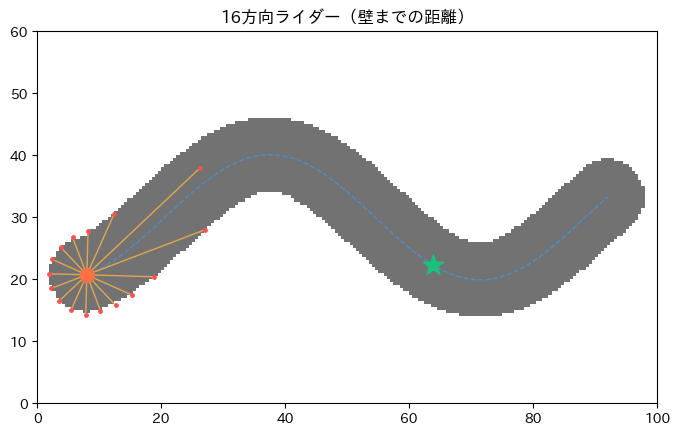

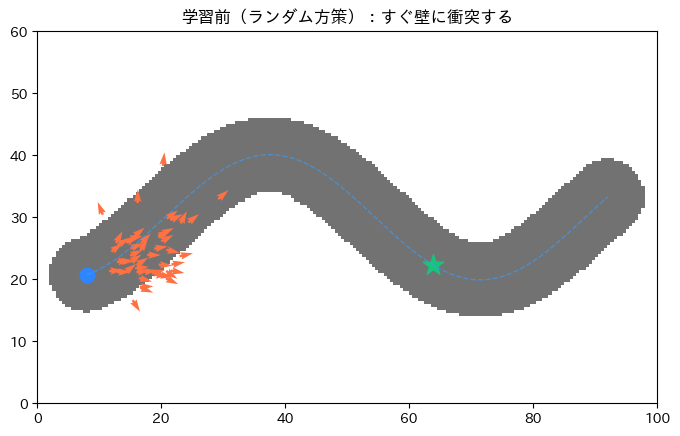

In [4]:
# --- 環境の動作確認：状態の形・16ライダーの可視化・ランダム走行の様子 ---
env = STrackEnv(n_cars=48, seed=2)
obs = env.reset()
print("状態ベクトルの形:", obs.shape, " (=16ライダー + 速度 + 進行方向誤差sin,cos)")
print("行動数:", env.n_actions, " (ハンドル3 × ペダル3)")
print("道路が占める面積の割合:", round(float(env.free.mean()), 3))

# 16方向ライダーの可視化（1台ぶん）
draw_lidar(env, car_idx=0)

# ランダム方策で一斉に走らせた様子（学習前）
env2 = STrackEnv(n_cars=48, seed=2)
frames = record_rollout(env2, agent=None, max_frames=80)
pos, th, done, reached = frames[min(45, len(frames)-1)]
fig, ax = plt.subplots(figsize=(8,5))
ax.imshow(env2.free, origin="lower", extent=[0,env2.WX,0,env2.WY], cmap="Greys",
          vmin=0, vmax=1.6, aspect="equal")
ax.plot(env2.cl[:,0], env2.cl[:,1], "--", color="#3aa0ff", lw=1, alpha=0.6)
ax.quiver(pos[:,0], pos[:,1], np.cos(th)*2.2, np.sin(th)*2.2, color="#ff7043",
          scale=1, scale_units="xy", angles="xy", width=0.004)
ax.scatter([env2.cl[0,0]],[env2.cl[0,1]], c="#2e86ff", s=110, marker="o")
ax.scatter([env2.goal_xy[0]],[env2.goal_xy[1]], c="#19c37d", s=240, marker="*")
ax.set_title("学習前（ランダム方策）：すぐ壁に衝突する"); ax.set_xlim(0,env2.WX); ax.set_ylim(0,env2.WY)
plt.show()


## 3. DQN エージェント（CartPole と同じ骨格）

部品は CartPole の DQN と同じです：Q関数の近似ネット・経験再生・ターゲットネット・ε-greedy・ベルマン更新。
違うのは「状態＝16ライダー＋速度＋向き誤差(19次元)」「行動＝9通り」「多数の車で経験を集める」点だけです。


In [5]:
# ============================================================================
# 【DQNエージェント】 CartPole のDQNと同じ骨格（部品は同じ）
#   ・QNet         : 状態(19次元) → 各行動(9個)のQ値。Q表の代わり（関数近似）
#   ・ReplayBuffer : 経験再生。多数の車の経験を1つのバッファに貯めてランダム学習
#   ・act_batch    : ε-greedy を全車まとめて（探索と活用）
#   ・replay       : ベルマン更新  L=( r + γ·maxQ(θ⁻) − Q(θ) )²  を最小化
#   ・target       : ターゲットネット（一定間隔で同期して学習を安定化）
# ============================================================================
import torch, torch.nn as nn, torch.nn.functional as F
from collections import deque
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("使用デバイス:", device)

class QNet(nn.Module):
    def __init__(self, obs_dim, n_act, h=128):
        super().__init__()
        self.f1 = nn.Linear(obs_dim, h)
        self.f2 = nn.Linear(h, h)
        self.f3 = nn.Linear(h, n_act)
    def forward(self, x):
        x = F.relu(self.f1(x))
        x = F.relu(self.f2(x))
        return self.f3(x)        # 出力 = 9個の行動それぞれのQ値

class DQNAgent:
    def __init__(self, obs_dim, n_act):
        self.n_act = n_act
        self.policy = QNet(obs_dim, n_act).to(device)   # 主ネット θ（学習中）
        self.target = QNet(obs_dim, n_act).to(device)   # ターゲットネット θ⁻（時々同期）
        self.target.load_state_dict(self.policy.state_dict())
        self.opt = torch.optim.Adam(self.policy.parameters(), 1e-3)
        self.buf = deque(maxlen=100000)                 # 経験再生バッファ
        self.bs = 256
        self.gamma = 0.99                               # 割引率 γ
        self.eps = 1.0; self.eps_min = 0.05; self.eps_decay = 0.995
        self.tgt_every = 500; self._c = 0

    # 全車まとめて ε-greedy で行動選択（探索：ランダム / 活用：Q最大）
    def act_batch(self, obs):
        n = obs.shape[0]
        a = np.random.randint(0, self.n_act, n)         # まず全車ランダム（探索）
        greedy = (np.random.rand(n) >= self.eps)        # 確率(1-ε)で活用に上書き
        if greedy.any():
            with torch.no_grad():
                q = self.policy(torch.tensor(obs[greedy], device=device))
            a[greedy] = q.argmax(1).cpu().numpy()
        return a

    # 多数の車の遷移をまとめてバッファに追加
    def remember_batch(self, s, a, r, s2, d):
        for i in range(len(a)):
            self.buf.append((s[i], a[i], r[i], s2[i], d[i]))

    # ベルマン更新（CartPole の replay() と中身は同じ）
    def replay(self):
        if len(self.buf) < self.bs:
            return None
        batch = random.sample(self.buf, self.bs)
        s, a, r, s2, d = zip(*batch)
        s  = torch.tensor(np.array(s),  device=device)
        a  = torch.tensor(np.array(a),  device=device).long().unsqueeze(1)
        r  = torch.tensor(np.array(r),  device=device).float()
        s2 = torch.tensor(np.array(s2), device=device)
        d  = torch.tensor(np.array(d),  device=device).bool()

        q  = self.policy(s).gather(1, a).squeeze(1)              # Q(s,a; θ): 現在の見積り
        with torch.no_grad():
            nq  = self.target(s2).max(1)[0]                     # max Q(s',·; θ⁻)
            tgt = r + self.gamma * nq * (~d)                    # r + γ·maxQ = TDターゲット
        loss = F.mse_loss(q, tgt)                               # (目標 − 現在)²
        self.opt.zero_grad(); loss.backward(); self.opt.step()

        self._c += 1
        if self._c % self.tgt_every == 0:                      # 時々ターゲットネットを同期
            self.target.load_state_dict(self.policy.state_dict())
        return loss.item()

print("DQNAgent 定義OK")


使用デバイス: cpu
DQNAgent 定義OK


## 4. 学習ループ（時々、走りを動画化）

多数の車で経験を集め、毎ステップ1回ベルマン更新します。
`video_every` エピソードごとに、その時点の方策で **別のコース** を走らせた動画を表示し、上達の様子を確認します。


In [6]:
# ============================================================================
# 【学習ループ】 多数の車で経験を集めてDQNを学習。時々、走行を動画化して進捗を見る
# ============================================================================
import time

def train(episodes=400, n_cars=48, seed=0, video_every=50, video_max_frames=200):
    np.random.seed(seed); torch.manual_seed(seed); random.seed(seed)
    env   = STrackEnv(n_cars=n_cars, seed=seed)        # 学習用（毎エピソード別のS字）
    eval_env = STrackEnv(n_cars=n_cars, seed=12345)    # 動画用（学習とは別のコース）
    agent = DQNAgent(env.obs_dim, env.n_actions)
    hist = []                                          # (ゴール率, 最大進捗, 平均進捗, 平均リターン)
    t0 = time.time()

    for ep in range(episodes):
        obs = env.reset()
        ep_ret = np.zeros(n_cars)
        while True:
            live = ~env.done
            a = agent.act_batch(obs)
            nobs, r, done, da = env.step(a)
            # 生きていた車の遷移だけ保存（既に終わった車は学習に入れない）
            idx = np.where(live)[0]
            if len(idx):
                agent.remember_batch(obs[idx], a[idx], r[idx], nobs[idx], done[idx])
            ep_ret += r
            obs = nobs
            agent.replay()                              # 毎ステップ1回ベルマン更新
            if da: break

        agent.eps = max(agent.eps_min, agent.eps*agent.eps_decay)
        hist.append((env.reached.mean(), env.s.max(), env.s.mean(), ep_ret.mean()))

        if ep % 10 == 0:
            rr, smax, smean, ret = hist[-1]
            print(f"ep{ep:4d}  ε={agent.eps:.2f}  ゴール率(探索中ε)={rr*100:4.0f}%  "
                  f"最大進捗={smax:.2f}  平均進捗={smean:.2f}  平均リターン={ret:6.1f}")

        # ---- 時々、現在の方策の走行を動画化して表示（探索オフ＝実力どおり）----
        if video_every and (ep % video_every == 0):
            frames = record_rollout(eval_env, agent, greedy=True, max_frames=video_max_frames)
            path = animate(eval_env, frames, path=f"train_ep{ep:04d}.mp4",
                           title=f"エピソード {ep}")
            print(f"  → 動画 train_ep{ep:04d}.mp4（評価ゴール率(貪欲ε=0) {eval_env.reached.mean()*100:.0f}%）")
            print(f"     ※ログの『ゴール率(探索中)』は約{int(agent.eps*100)}%がランダム行動なので低く出る。実力はこの貪欲評価が正しい。")
            show_video(path)

    print(f"学習時間 {time.time()-t0:.1f}s")
    return env, agent, hist

print("train() 定義OK")


train() 定義OK


## 5. 学習の実行

`episodes` を増やすほど上達します（**GPU推奨**）。途中で何本か走行動画が表示されます。
最初はすぐ壁にぶつかりますが、徐々に道なりに曲がり、速度も使ってゴールまで走り抜けるようになります。


In [7]:
# --- 学習の実行 ---
#   GPU 推奨（ランタイム → ランタイムのタイプを変更 → GPU）。
#   episodes を増やすほど上達する。video_every ごとに走行動画が表示される。
trained_env, agent, hist = train(episodes=400, n_cars=48, seed=0, video_every=80)


ep   0  ε=0.99  ゴール率(探索中ε)=   0%  最大進捗=0.43  平均進捗=0.16  平均リターン=  -1.7
  → 動画 train_ep0000.mp4（評価ゴール率(貪欲ε=0) 10%）
     ※ログの『ゴール率(探索中)』は約99%がランダム行動なので低く出る。実力はこの貪欲評価が正しい。


ep  10  ε=0.95  ゴール率(探索中ε)=   2%  最大進捗=0.70  平均進捗=0.18  平均リターン=   0.7
ep  20  ε=0.90  ゴール率(探索中ε)=   0%  最大進捗=0.56  平均進捗=0.18  平均リターン=   0.3
ep  30  ε=0.86  ゴール率(探索中ε)=   2%  最大進捗=0.69  平均進捗=0.22  平均リターン=   3.6
ep  40  ε=0.81  ゴール率(探索中ε)=   0%  最大進捗=0.36  平均進捗=0.13  平均リターン=  -1.5
ep  50  ε=0.77  ゴール率(探索中ε)=   0%  最大進捗=0.60  平均進捗=0.28  平均リターン=   7.2
ep  60  ε=0.74  ゴール率(探索中ε)=   0%  最大進捗=0.58  平均進捗=0.20  平均リターン=   2.8
ep  70  ε=0.70  ゴール率(探索中ε)=   2%  最大進捗=0.73  平均進捗=0.22  平均リターン=   4.9
ep  80  ε=0.67  ゴール率(探索中ε)=   2%  最大進捗=0.72  平均進捗=0.20  平均リターン=   3.7
  → 動画 train_ep0080.mp4（評価ゴール率(貪欲ε=0) 100%）
     ※ログの『ゴール率(探索中)』は約66%がランダム行動なので低く出る。実力はこの貪欲評価が正しい。


ep  90  ε=0.63  ゴール率(探索中ε)=   8%  最大進捗=0.71  平均進捗=0.28  平均リターン=   9.6
ep 100  ε=0.60  ゴール率(探索中ε)=   8%  最大進捗=0.69  平均進捗=0.33  平均リターン=  12.6
ep 110  ε=0.57  ゴール率(探索中ε)=   4%  最大進捗=0.70  平均進捗=0.25  平均リターン=   6.9
ep 120  ε=0.55  ゴール率(探索中ε)=   0%  最大進捗=0.56  平均進捗=0.20  平均リターン=   3.4
ep 130  ε=0.52  ゴール率(探索中ε)=   6%  最大進捗=0.69  平均進捗=0.31  平均リターン=  11.3
ep 140  ε=0.49  ゴール率(探索中ε)=  17%  最大進捗=0.73  平均進捗=0.36  平均リターン=  16.7
ep 150  ε=0.47  ゴール率(探索中ε)=   0%  最大進捗=0.50  平均進捗=0.18  平均リターン=   2.6
ep 160  ε=0.45  ゴール率(探索中ε)=   4%  最大進捗=0.73  平均進捗=0.27  平均リターン=   8.8
  → 動画 train_ep0160.mp4（評価ゴール率(貪欲ε=0) 100%）
     ※ログの『ゴール率(探索中)』は約44%がランダム行動なので低く出る。実力はこの貪欲評価が正しい。


ep 170  ε=0.42  ゴール率(探索中ε)=   0%  最大進捗=0.72  平均進捗=0.21  平均リターン=   4.1
ep 180  ε=0.40  ゴール率(探索中ε)=  12%  最大進捗=0.71  平均進捗=0.35  平均リターン=  15.4
ep 190  ε=0.38  ゴール率(探索中ε)=  10%  最大進捗=0.74  平均進捗=0.35  平均リターン=  14.6
ep 200  ε=0.37  ゴール率(探索中ε)=  12%  最大進捗=0.74  平均進捗=0.42  平均リターン=  19.3
ep 210  ε=0.35  ゴール率(探索中ε)=  10%  最大進捗=0.76  平均進捗=0.38  平均リターン=  16.4
ep 220  ε=0.33  ゴール率(探索中ε)=  12%  最大進捗=0.75  平均進捗=0.30  平均リターン=  12.0
ep 230  ε=0.31  ゴール率(探索中ε)=  19%  最大進捗=0.67  平均進捗=0.38  平均リターン=  18.5
ep 240  ε=0.30  ゴール率(探索中ε)=  23%  最大進捗=0.71  平均進捗=0.37  平均リターン=  18.7
  → 動画 train_ep0240.mp4（評価ゴール率(貪欲ε=0) 77%）
     ※ログの『ゴール率(探索中)』は約29%がランダム行動なので低く出る。実力はこの貪欲評価が正しい。


ep 250  ε=0.28  ゴール率(探索中ε)=  46%  最大進捗=0.73  平均進捗=0.54  平均リターン=  33.9
ep 260  ε=0.27  ゴール率(探索中ε)=  25%  最大進捗=0.76  平均進捗=0.45  平均リターン=  23.8
ep 270  ε=0.26  ゴール率(探索中ε)=  35%  最大進捗=0.67  平均進捗=0.50  平均リターン=  29.8
ep 280  ε=0.24  ゴール率(探索中ε)=  35%  最大進捗=0.70  平均進捗=0.49  平均リターン=  28.8
ep 290  ε=0.23  ゴール率(探索中ε)=  12%  最大進捗=0.73  平均進捗=0.37  平均リターン=  16.8
ep 300  ε=0.22  ゴール率(探索中ε)=  44%  最大進捗=0.73  平均進捗=0.51  平均リターン=  32.1
ep 310  ε=0.21  ゴール率(探索中ε)=  81%  最大進捗=0.73  平均進捗=0.67  平均リターン=  50.3
ep 320  ε=0.20  ゴール率(探索中ε)=  33%  最大進捗=0.76  平均進捗=0.48  平均リターン=  26.6
  → 動画 train_ep0320.mp4（評価ゴール率(貪欲ε=0) 71%）
     ※ログの『ゴール率(探索中)』は約20%がランダム行動なので低く出る。実力はこの貪欲評価が正しい。


ep 330  ε=0.19  ゴール率(探索中ε)=  65%  最大進捗=0.69  平均進捗=0.58  平均リターン=  41.0
ep 340  ε=0.18  ゴール率(探索中ε)=  58%  最大進捗=0.71  平均進捗=0.57  平均リターン=  38.5
ep 350  ε=0.17  ゴール率(探索中ε)=  35%  最大進捗=0.70  平均進捗=0.49  平均リターン=  26.8
ep 360  ε=0.16  ゴール率(探索中ε)=  62%  最大進捗=0.70  平均進捗=0.58  平均リターン=  39.1
ep 370  ε=0.16  ゴール率(探索中ε)=  44%  最大進捗=0.68  平均進捗=0.52  平均リターン=  31.2
ep 380  ε=0.15  ゴール率(探索中ε)=  60%  最大進捗=0.73  平均進捗=0.58  平均リターン=  39.0
ep 390  ε=0.14  ゴール率(探索中ε)=  25%  最大進捗=0.78  平均進捗=0.49  平均リターン=  25.3
学習時間 403.5s


## 6. 結果 — 学習曲線と最終走行

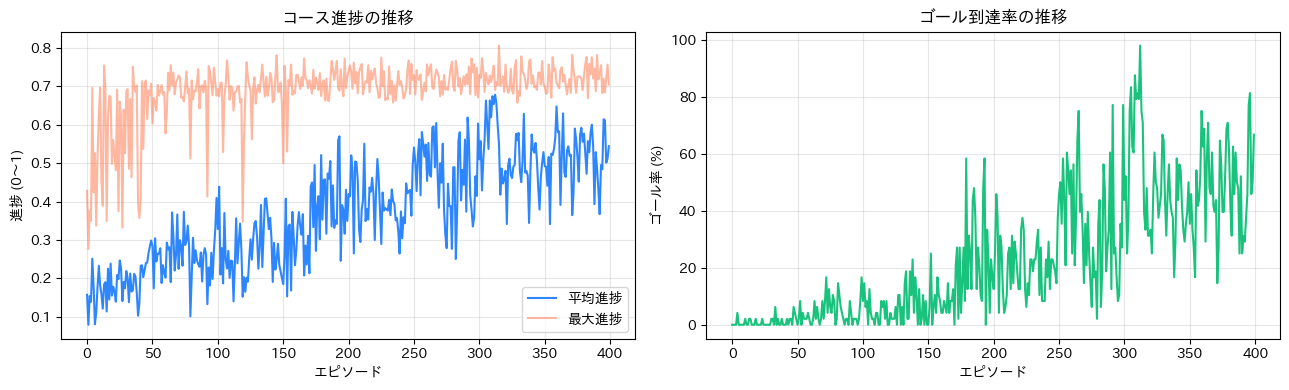

ゴール率: 100%


In [8]:
# --- 学習曲線（平均進捗・ゴール率の推移）---
H = np.array(hist)  # 列: ゴール率, 最大進捗, 平均進捗, 平均リターン
ep = np.arange(len(H))
fig, ax = plt.subplots(1, 2, figsize=(13,4))
ax[0].plot(ep, H[:,2], color="#2e86ff", label="平均進捗")
ax[0].plot(ep, H[:,1], color="#ff7043", alpha=0.5, label="最大進捗")
ax[0].set_xlabel("エピソード"); ax[0].set_ylabel("進捗 (0〜1)")
ax[0].set_title("コース進捗の推移"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(ep, H[:,0]*100, color="#19c37d")
ax[1].set_xlabel("エピソード"); ax[1].set_ylabel("ゴール率 (%)")
ax[1].set_title("ゴール到達率の推移"); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

# --- 学習後の方策で、新しいS字コースを走らせた最終動画 ---
final_env = STrackEnv(n_cars=48, seed=999)
frames = record_rollout(final_env, agent, greedy=True, max_frames=250)
path = animate(final_env, frames, path="final_policy.mp4", title="学習後の走行（新コース）")
print(f"ゴール率: {final_env.reached.mean()*100:.0f}%")
show_video(path)


## 7. まとめと発展

**設計の意図**
- 状態を「16方向の距離」に絞ることで、コース形状が変わっても同じ方策が使える（汎化）。
- 行動を9通りに離散化したので、CartPole と同じ DQN がそのまま使える。
- 報酬は「前進＋速度＋ゴール − 衝突 − 失速 − 時間」。速度報酬と失速罰で「止まる」抜け道を塞ぎ、時間ペナルティが「速くゴール」を促す。
- ゴールは末端の行き止まりより手前に置き、ゴール前方に壁を見せない。
- 多数の車を並列に走らせるのは経験を速く集めるため（車どうしは衝突させない）。

**調整ポイント**
- `R_PROGRESS / R_SPEED / R_TIME / R_CRASH / R_GOAL / R_STALL`：走りの性格（安全寄り／攻め）が変わる
- `half_w`（道幅）、`cycles`（うねりの強さ）、`VMAX`、`MAXSTEER`：難易度
- `n_cars`、`episodes`、`eps_decay`：学習の速さ・安定性

**発展課題**
- 連続制御（DDPG / PPO）でハンドル・アクセルを連続値にする
- 車どうしの衝突も入れて、追い越し・譲り合いを学習させる
- ライダーの本数・角度範囲を変えて、知覚と性能の関係を調べる
- 報酬を設計し直して「安全運転」「レース」など性格の違う方策を作る（CartPole のカスタム報酬と同じ発想）
